# ChromaDB Explorer — AI-DJ Track Collection
Inspect embeddings, metadata, similarity search, and embedding space structure.

In [2]:
import sys
sys.path.insert(0, '..')  # so we can import from src/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chromadb

from src.features.vector_store import get_client, get_collection, query_hard_negatives

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

## 1. Connect and basic health check

In [3]:
client = get_client('../data/processed/chromadb')
col    = get_collection(client)

print(f"Collection : {col.name}")
print(f"Track count: {col.count()}")
print(f"Metadata   : {col.metadata}")

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Collection : tracks
Track count: 33
Metadata   : {'hnsw:space': 'cosine'}


## 2. Peek — first N records

In [8]:
N = 5
peek = col.peek(N)

df_peek = pd.DataFrame(peek['metadatas'], index=peek['ids'])
df_peek.index.name = 'track_id'
df_peek

,bpm,energy_mean,energy_std,key,loudness_lufs,mfcc_0,mfcc_1,mfcc_10,mfcc_11,mfcc_12,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,onset_strength,spectral_centroid
track_id,,,,,,,,,,,,,,,,,,,,
09ac75ecc78d,135.999,0.406,0.095,Em,-6.690,3.761,65.754,0.396,6.428,1.868,11.736,12.367,18.303,16.738,3.566,11.911,3.774,8.618,1.996,2874.790
20ec41efac94,95.703,0.226,0.064,E,-10.506,-1.425,89.326,-6.052,5.264,1.401,1.088,10.105,-2.806,7.737,2.395,6.283,-8.322,7.266,1.057,2631.817
26b742a8b049,143.555,0.334,0.115,C#m,-8.013,-17.366,77.111,5.291,6.832,0.306,2.681,12.889,13.570,24.842,7.358,5.080,5.557,6.966,1.901,2513.158
299218015fc8,135.999,0.363,0.134,F#m,-8.005,-154.471,111.749,1.511,5.420,0.885,54.599,32.662,19.184,22.148,9.547,12.816,5.448,10.499,2.014,1550.255
33d063e88eb9,143.555,0.373,0.150,Cm,-6.749,-40.582,62.541,6.598,10.589,1.978,-6.719,15.377,0.755,26.313,5.617,18.482,-3.834,8.762,1.591,2694.157


## 3. Fetch all records into a DataFrame

In [9]:
all_records = col.get(include=['embeddings', 'metadatas'])

df_meta = pd.DataFrame(all_records['metadatas'], index=all_records['ids'])
df_meta.index.name = 'track_id'
embeddings = np.array(all_records['embeddings'])  # shape: (n_tracks, 768)

print(f"Metadata shape  : {df_meta.shape}")
print(f"Embeddings shape: {embeddings.shape}")
df_meta.describe()

Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


Metadata shape  : (33, 20)
Embeddings shape: (33, 768)


,bpm,energy_mean,energy_std,loudness_lufs,mfcc_0,mfcc_1,mfcc_10,mfcc_11,mfcc_12,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,onset_strength,spectral_centroid
count,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000,33.000
mean,133.654,0.330,0.108,-8.874,-67.098,86.615,0.474,5.118,0.517,9.741,21.705,9.673,16.672,4.392,8.628,2.371,8.248,1.880,2266.283
std,17.843,0.111,0.045,3.116,63.072,27.851,6.889,5.950,5.359,21.802,12.890,12.825,8.341,10.477,6.770,8.715,5.443,0.433,640.803
min,92.285,0.101,0.027,-16.923,-273.926,44.130,-19.120,-13.097,-17.795,-20.726,-5.540,-24.601,-4.036,-20.164,-5.459,-27.209,-10.366,1.057,261.495
25%,135.999,0.244,0.073,-10.099,-83.414,65.754,-2.018,3.197,-1.357,-2.580,13.574,0.764,13.188,2.395,5.726,-1.154,6.399,1.615,1797.565
50%,135.999,0.365,0.115,-7.949,-58.188,81.350,1.511,6.428,0.885,3.738,21.128,9.421,16.398,5.649,10.011,4.162,8.762,1.879,2493.150
75%,143.555,0.397,0.142,-6.960,-21.344,105.065,4.436,7.964,2.967,15.381,26.844,19.528,22.148,9.547,12.816,5.860,10.499,2.014,2748.785
max,161.499,0.521,0.186,-4.946,22.944,166.678,16.862,18.230,13.360,81.297,56.711,32.951,35.547,24.881,20.890,19.971,18.560,3.065,3190.663


## 4. Metadata distributions

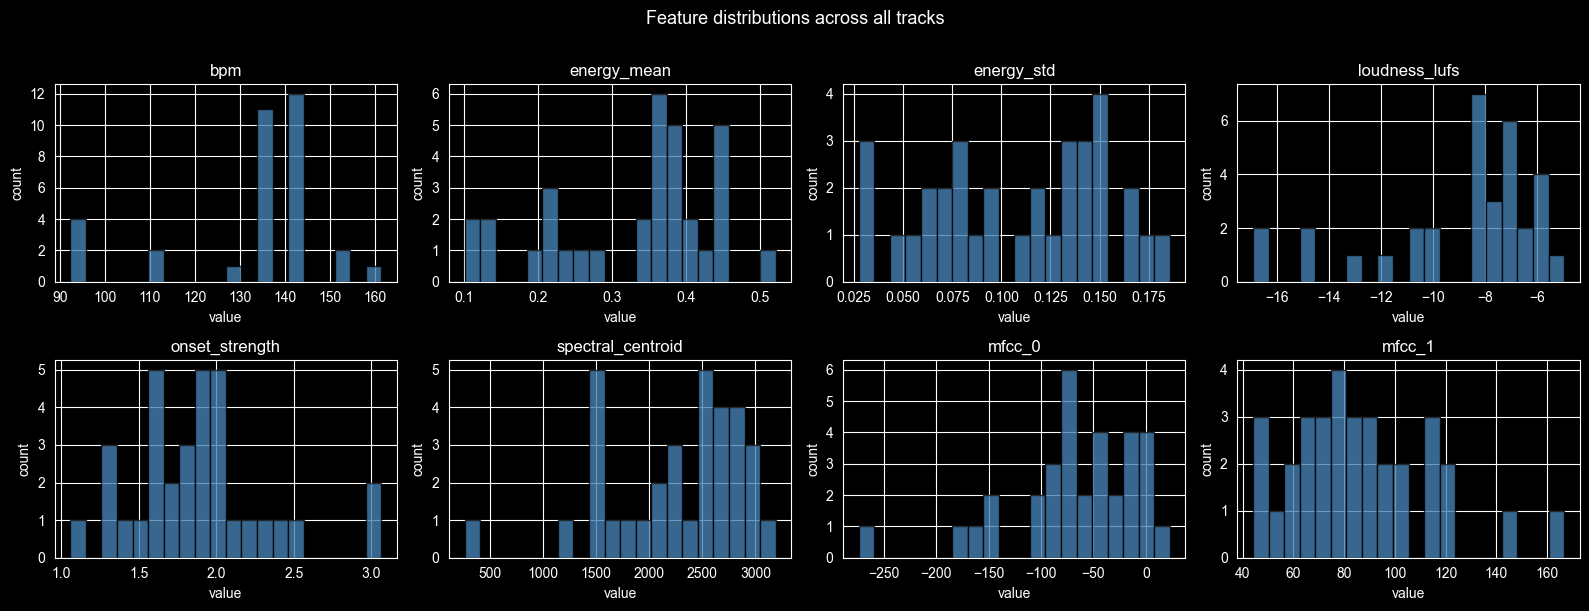

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

plot_cols = ['bpm', 'energy_mean', 'energy_std', 'loudness_lufs',
             'onset_strength', 'spectral_centroid', 'mfcc_0', 'mfcc_1']

for ax, col_name in zip(axes, plot_cols):
    data = df_meta[col_name].dropna()
    ax.hist(data, bins=20, edgecolor='black', color='steelblue', alpha=0.8)
    ax.set_title(col_name)
    ax.set_xlabel('value')
    ax.set_ylabel('count')

plt.suptitle('Feature distributions across all tracks', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Key distribution

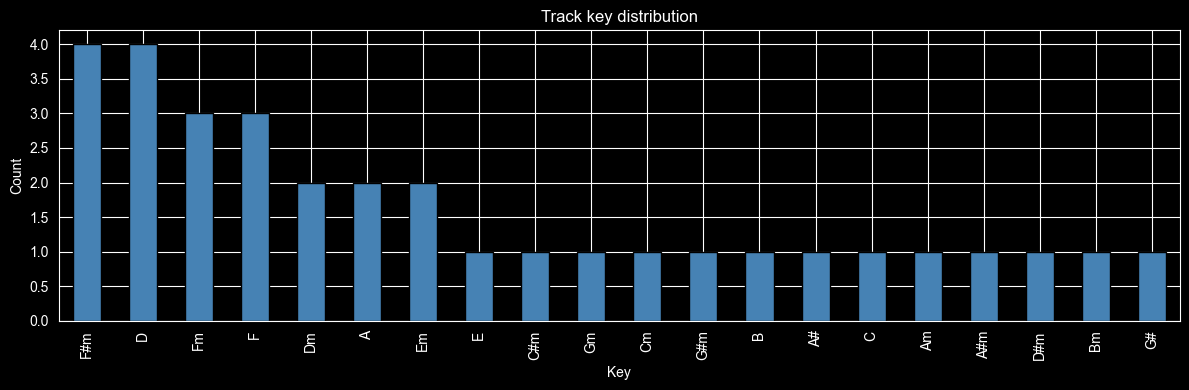

key
F#m    4
D      4
Fm     3
F      3
Dm     2
A      2
Em     2
E      1
C#m    1
Gm     1
Cm     1
G#m    1
B      1
A#     1
C      1
Am     1
A#m    1
D#m    1
Bm     1
G#     1
Name: count, dtype: int64


In [11]:
key_counts = df_meta['key'].value_counts()

fig, ax = plt.subplots(figsize=(12, 4))
key_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Track key distribution')
ax.set_xlabel('Key')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(key_counts)

## 6. Embedding health — are there dead/zero vectors?

Norm stats — min: 6.0620  max: 8.5770  mean: 7.1731
No dead embeddings. All vectors look healthy.


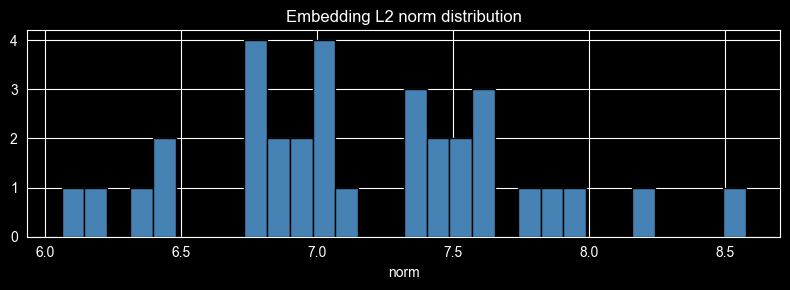

In [12]:
norms = np.linalg.norm(embeddings, axis=1)

print(f"Norm stats — min: {norms.min():.4f}  max: {norms.max():.4f}  mean: {norms.mean():.4f}")

dead = np.where(norms < 0.01)[0]
if len(dead):
    print(f"WARNING: {len(dead)} near-zero embeddings (dead vectors):")
    print([all_records['ids'][i] for i in dead])
else:
    print("No dead embeddings. All vectors look healthy.")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(norms, bins=30, edgecolor='black', color='steelblue')
ax.set_title('Embedding L2 norm distribution')
ax.set_xlabel('norm')
plt.tight_layout()
plt.show()

## 7. Useful dimensions — how many dims carry signal?

Dimensions with variance > 1e-4: 768 / 768
(MERT target: ~767/768  |  CLAP baseline was 89/512)


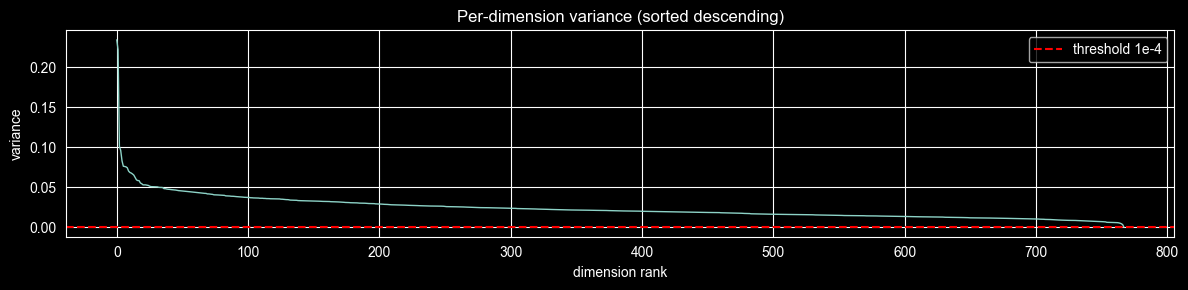

In [13]:
variances = embeddings.var(axis=0)
useful_dims = (variances > 1e-4).sum()

print(f"Dimensions with variance > 1e-4: {useful_dims} / {embeddings.shape[1]}")
print(f"(MERT target: ~767/768  |  CLAP baseline was 89/512)")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(sorted(variances, reverse=True), lw=1)
ax.axhline(1e-4, color='red', linestyle='--', label='threshold 1e-4')
ax.set_title('Per-dimension variance (sorted descending)')
ax.set_xlabel('dimension rank')
ax.set_ylabel('variance')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Cosine similarity heatmap — all pairs

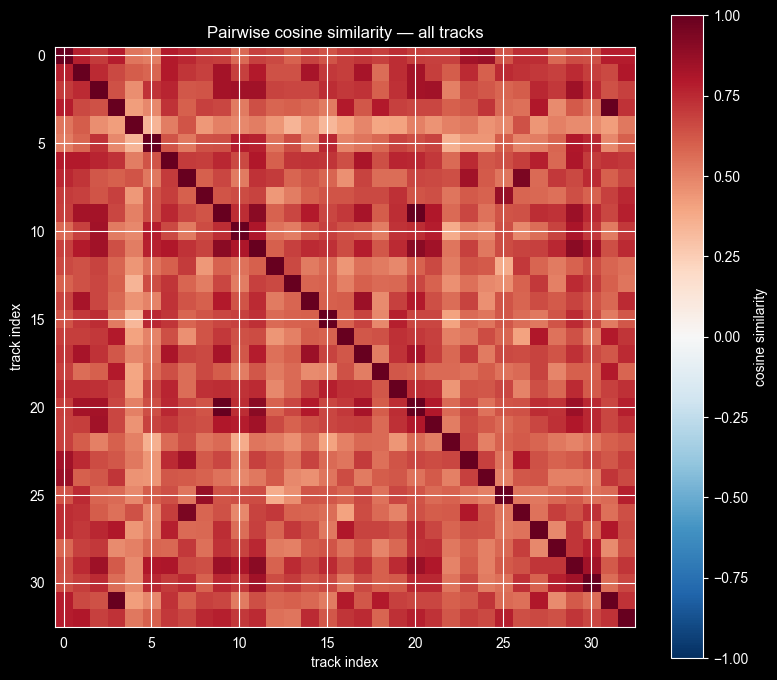

Off-diagonal cosine sim — mean: 0.6396  std: 0.1101  min: 0.3346  max: 1.0000


In [14]:
# Normalise to unit sphere first (cosine sim = dot product after normalisation)
normed = embeddings / (norms[:, None] + 1e-9)
sim_matrix = normed @ normed.T  # (n_tracks, n_tracks)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim_matrix, vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar(im, ax=ax, label='cosine similarity')
ax.set_title('Pairwise cosine similarity — all tracks')
ax.set_xlabel('track index')
ax.set_ylabel('track index')
plt.tight_layout()
plt.show()

# Summary stats (exclude diagonal)
mask = ~np.eye(len(sim_matrix), dtype=bool)
off_diag = sim_matrix[mask]
print(f"Off-diagonal cosine sim — mean: {off_diag.mean():.4f}  std: {off_diag.std():.4f}  min: {off_diag.min():.4f}  max: {off_diag.max():.4f}")

## 9. Nearest-neighbour query — find similar tracks to an anchor

In [15]:
# Pick an anchor track — change this to any track_id in the collection
anchor_id = all_records['ids'][0]
print(f"Anchor: {anchor_id}")
print("Anchor metadata:", all_records['metadatas'][0])

anchor_emb = embeddings[0]

results = col.query(
    query_embeddings=[anchor_emb.tolist()],
    n_results=10,
    include=['metadatas', 'distances'],
)

df_nn = pd.DataFrame(results['metadatas'][0], index=results['ids'][0])
df_nn.insert(0, 'cosine_distance', results['distances'][0])
df_nn.index.name = 'track_id'
df_nn

Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Anchor: 09ac75ecc78d
Anchor metadata: {'bpm': 135.99917763157896, 'energy_mean': 0.4064638912677765, 'energy_std': 0.09508589655160904, 'key': 'Em', 'loudness_lufs': -6.690127994124723, 'mfcc_0': 3.761064052581787, 'mfcc_1': 65.7543716430664, 'mfcc_10': 0.39590299129486084, 'mfcc_11': 6.428157806396484, 'mfcc_12': 1.868087649345398, 'mfcc_2': 11.736413955688477, 'mfcc_3': 12.36740493774414, 'mfcc_4': 18.303007125854492, 'mfcc_5': 16.738300323486328, 'mfcc_6': 3.5656888484954834, 'mfcc_7': 11.910680770874023, 'mfcc_8': 3.773839235305786, 'mfcc_9': 8.617964744567871, 'onset_strength': 1.99566650390625, 'spectral_centroid': 2874.7897939207915}


,cosine_distance,bpm,energy_mean,energy_std,key,loudness_lufs,mfcc_0,mfcc_1,mfcc_10,mfcc_11,mfcc_12,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,onset_strength,spectral_centroid
track_id,,,,,,,,,,,,,,,,,,,,,
09ac75ecc78d,0.000,135.999,0.406,0.095,Em,-6.690,3.761,65.754,0.396,6.428,1.868,11.736,12.367,18.303,16.738,3.566,11.911,3.774,8.618,1.996,2874.790
b42878fd7de4,12.464,143.555,0.453,0.098,C,-8.481,-77.845,105.353,5.229,9.695,0.624,35.736,24.196,19.601,15.226,14.348,7.592,5.947,9.895,2.000,1725.454
b86b337c54fd,14.213,135.999,0.378,0.070,Am,-7.827,-69.951,44.130,12.419,7.964,5.422,15.381,43.618,20.766,26.249,24.881,16.570,19.971,12.341,1.899,2602.106
20ec41efac94,17.918,95.703,0.226,0.064,E,-10.506,-1.425,89.326,-6.052,5.264,1.401,1.088,10.105,-2.806,7.737,2.395,6.283,-8.322,7.266,1.057,2631.817
47691dbe4eb2,18.864,143.555,0.210,0.048,D,-11.954,-54.467,89.684,-0.319,7.664,-1.991,20.457,11.992,14.254,17.916,13.781,9.768,5.382,9.171,1.615,2386.921
f25b03307887,19.495,135.999,0.244,0.186,Dm,-8.321,-107.157,47.767,0.413,6.722,-3.281,-1.213,21.734,-15.383,12.822,-7.624,8.928,-1.199,6.539,1.615,3029.568
c4f5e5e85446,21.781,135.999,0.365,0.140,Em,-7.191,-9.756,79.780,-0.158,2.224,1.812,-1.368,3.169,19.652,15.127,2.828,12.041,-0.856,6.995,2.086,2512.377
e06373a798b3,22.189,135.999,0.363,0.134,F#m,-8.005,-154.471,111.749,1.511,5.420,0.885,54.599,32.662,19.184,22.148,9.547,12.816,5.448,10.499,2.014,1550.255
299218015fc8,22.189,135.999,0.363,0.134,F#m,-8.005,-154.471,111.749,1.511,5.420,0.885,54.599,32.662,19.184,22.148,9.547,12.816,5.448,10.499,2.014,1550.255


## 10. Semi-hard negative mining — what the training loop uses

In [16]:
# Simulate what Phase 5 train_model.py does for each anchor
hard_negs = query_hard_negatives(
    col,
    embedding=anchor_emb,
    n_results=10,
    exclude_ids=[anchor_id],   # in training: also exclude positive pair track_id
    min_distance=0.10,         # below this → likely false negative
    max_distance=0.60,         # above this → too easy, no training signal
)

if hard_negs['ids'][0]:
    df_hn = pd.DataFrame(hard_negs['metadatas'][0], index=hard_negs['ids'][0])
    df_hn.insert(0, 'cosine_distance', hard_negs['distances'][0])
    df_hn.index.name = 'track_id'
    print(f"Found {len(df_hn)} hard negatives in window [0.10, 0.60]")
    display(df_hn)
else:
    print("No semi-hard negatives found for this anchor in the current window.")
    print("Expected with small collections (<50 tracks) — window may be too tight.")

No semi-hard negatives found for this anchor in the current window.
Expected with small collections (<50 tracks) — window may be too tight.


## 11. Distance distribution — visualise the semi-hard window

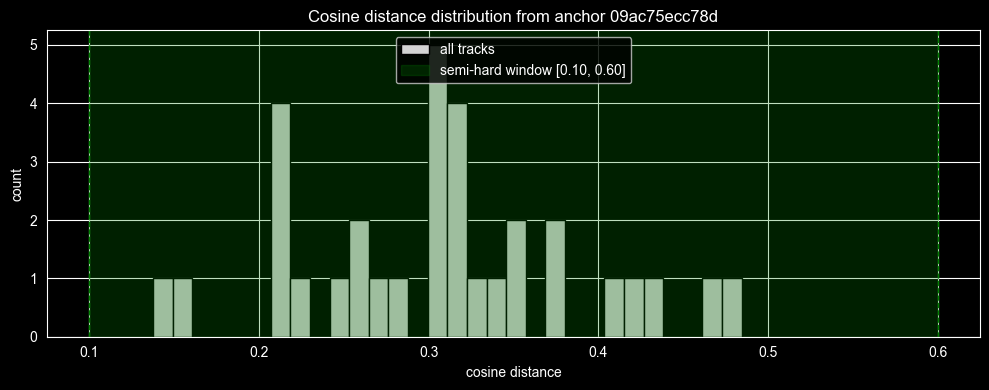

Tracks in semi-hard window: 32 / 32


In [17]:
# All pairwise cosine distances from the anchor
anchor_sims = normed @ normed[0]          # cosine similarities to anchor
anchor_dists = 1 - anchor_sims            # ChromaDB uses 1 - cosine_sim as distance
anchor_dists = anchor_dists[anchor_dists > 1e-6]  # drop the anchor itself

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(anchor_dists, bins=30, edgecolor='black', color='lightgray', label='all tracks')
ax.axvspan(0.10, 0.60, alpha=0.25, color='green', label='semi-hard window [0.10, 0.60]')
ax.axvline(0.10, color='green', linestyle='--', lw=1)
ax.axvline(0.60, color='green', linestyle='--', lw=1)
ax.set_title(f'Cosine distance distribution from anchor {anchor_id}')
ax.set_xlabel('cosine distance')
ax.set_ylabel('count')
ax.legend()
plt.tight_layout()
plt.show()

in_window = ((anchor_dists >= 0.10) & (anchor_dists <= 0.60)).sum()
print(f"Tracks in semi-hard window: {in_window} / {len(anchor_dists)}")

## 12. UMAP — visualise the embedding space
> Install if needed: `pip install umap-learn`

In [ ]:
try:
    import umap

    reducer = umap.UMAP(n_neighbors=min(15, len(embeddings) - 1), metric='cosine', random_state=42)
    proj = reducer.fit_transform(embeddings)  # (n_tracks, 2)

    # Colour by BPM
    bpm_vals = df_meta['bpm'].values

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # BPM colouring
    sc = axes[0].scatter(proj[:, 0], proj[:, 1], c=bpm_vals, cmap='viridis', s=60, alpha=0.8)
    plt.colorbar(sc, ax=axes[0], label='BPM')
    axes[0].set_title('UMAP — coloured by BPM')

    # Energy colouring
    energy_vals = df_meta['energy_mean'].values
    sc2 = axes[1].scatter(proj[:, 0], proj[:, 1], c=energy_vals, cmap='plasma', s=60, alpha=0.8)
    plt.colorbar(sc2, ax=axes[1], label='energy_mean')
    axes[1].set_title('UMAP — coloured by energy_mean')

    plt.suptitle('UMAP projection of 768-dim MERT embeddings (cosine)', fontsize=12)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("umap-learn not installed. Run: pip install umap-learn")

## 13. Metadata filter — query with where clause

In [18]:
# Example: tracks with BPM > 130
# ChromaDB where syntax uses $gt, $lt, $gte, $lte, $eq, $ne
filtered = col.get(
    where={"bpm": {"$gt": 130.0}},
    include=['metadatas'],
)

df_filtered = pd.DataFrame(filtered['metadatas'], index=filtered['ids'])
df_filtered.index.name = 'track_id'
print(f"Tracks with BPM > 130: {len(df_filtered)}")
df_filtered[['bpm', 'energy_mean', 'key', 'loudness_lufs']].sort_values('bpm', ascending=False)

Tracks with BPM > 130: 26


,bpm,energy_mean,key,loudness_lufs
track_id,,,,
acec88630d8a,161.499,0.348,F,-7.949
5a658179329f,151.999,0.454,Gm,-6.141
ba28dcb711f1,151.999,0.454,A#m,-4.946
33d063e88eb9,143.555,0.373,Cm,-6.749
633ebbfa1d73,143.555,0.261,D,-9.918
47691dbe4eb2,143.555,0.210,D,-11.954
676cf03b346b,143.555,0.218,Fm,-13.092
a5c89149eb81,143.555,0.441,Fm,-5.828
57aa01ace125,143.555,0.426,F#m,-6.994


## 14. BPM vs energy scatter

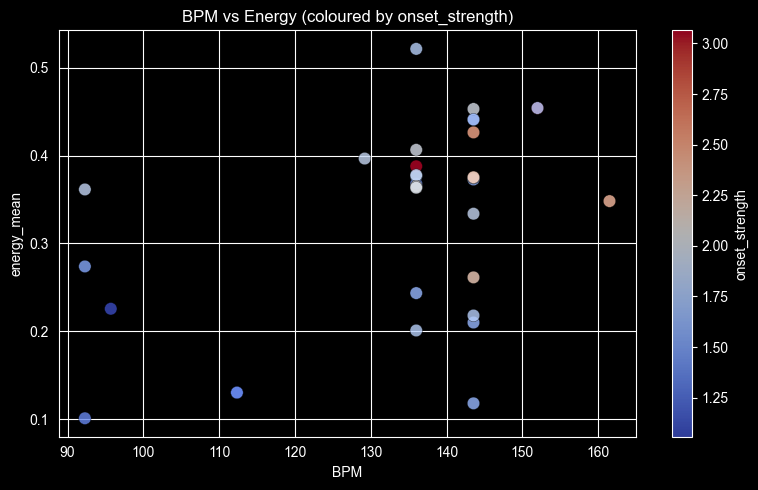

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(
    df_meta['bpm'],
    df_meta['energy_mean'],
    c=df_meta['onset_strength'],
    cmap='coolwarm',
    s=80,
    alpha=0.8,
    edgecolors='black',
    linewidths=0.3,
)
plt.colorbar(sc, ax=ax, label='onset_strength')
ax.set_xlabel('BPM')
ax.set_ylabel('energy_mean')
ax.set_title('BPM vs Energy (coloured by onset_strength)')
plt.tight_layout()
plt.show()